# Superstore Sales Forecast

Time-series forecasting using Facebook Prophet, applied to daily sales totals from the Superstore dataset (2015-2018).

In [3]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

In [4]:
# load daily sales from csv
df = pd.read_csv('../data/orders.csv', parse_dates=['Order Date'], dayfirst=True)
df = df.groupby('Order Date')['Sales'].sum().reset_index()
df.columns = ['order_date', 'daily_sales']
df['order_date'] = df['order_date'].dt.date

print(f"Loaded {len(df)} daily records")
df.head()


Loaded 1230 daily records


,order_date,daily_sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [5]:
# basic stats
print(df.describe())
print(f"\nDate range: {df['order_date'].min()} to {df['order_date'].max()}")

        daily_sales
count   1230.000000
mean    1838.647791
std     2295.418267
min        2.025000
25%      378.519000
50%     1058.397000
75%     2382.217000
max    28106.716000

Date range: 2015-01-03 to 2018-12-30


**Observations:**
- Daily sales are highly volatile (std $2,295 > mean $1,839)
- Right-skewed distribution - a few big days pull the mean up
- 1,230 days with orders across 4 years (Sundays show no activity)
- Forecasts will need uncertainty bands, not point estimates

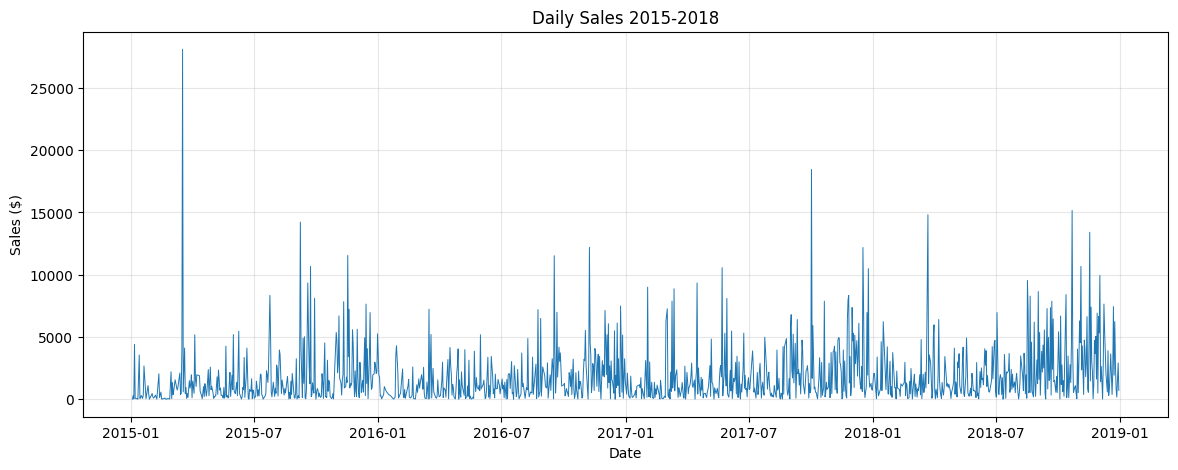

In [6]:
# plot daily sales over time
plt.figure(figsize=(14, 5))
plt.plot(df['order_date'], df['daily_sales'], linewidth=0.7)
plt.title('Daily Sales 2015-2018')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.grid(alpha=0.3)
plt.show()

In [7]:
# rename for prophet
prophet_df = df.rename(columns={'order_date': 'ds', 'daily_sales': 'y'})
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])
prophet_df.head()

,ds,y
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [8]:
# split: train on all but last 7 days, test on last 7
train = prophet_df[:-7]
test = prophet_df[-7:]

print(f"Train: {len(train)} rows ({train['ds'].min().date()} to {train['ds'].max().date()})")
print(f"Test:  {len(test)} rows ({test['ds'].min().date()} to {test['ds'].max().date()})")

Train: 1223 rows (2015-01-03 to 2018-12-23)
Test:  7 rows (2018-12-24 to 2018-12-30)


In [9]:
# fit on train, predict test window
model_val = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
model_val.fit(train)

future_val = model_val.make_future_dataframe(periods=7)
forecast_val = model_val.predict(future_val)

predicted = forecast_val.tail(7)[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].reset_index(drop=True)
predicted

12:28:27 - cmdstanpy - INFO - Chain [1] start processing
12:28:27 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
0,2018-12-24,3044.881579,286.358431,5729.686456
1,2018-12-25,3338.808508,460.327722,5871.308463
2,2018-12-26,2792.171926,142.255457,5515.581818
3,2018-12-27,2131.054618,-582.183180,4842.336666
4,2018-12-28,2639.201581,43.016676,5390.204967
5,2018-12-29,2969.312185,428.954750,5783.243929
6,2018-12-30,2635.992711,-111.264317,5244.498517


In [10]:
# compare predicted vs actual
comparison = test.reset_index(drop=True).copy()
comparison['predicted'] = predicted['yhat'].values
comparison['error'] = comparison['y'] - comparison['predicted']
comparison['abs_pct_error'] = (comparison['error'].abs() / comparison['y']) * 100
comparison

,ds,y,predicted,error,abs_pct_error
0,2018-12-24,6233.0540,3044.881579,3188.172421,51.149443
1,2018-12-25,2698.9270,3338.808508,-639.881508,23.708737
2,2018-12-26,814.5940,2792.171926,-1977.577926,242.768536
3,2018-12-27,177.6360,2131.054618,-1953.418618,1099.674963
4,2018-12-28,1657.3508,2639.201581,-981.850781,59.242182
5,2018-12-29,2915.5340,2969.312185,-53.778185,1.844540
6,2018-12-30,713.7900,2635.992711,-1922.202711,269.295270


In [11]:
# error metrics
mae = comparison['error'].abs().mean()
mape = comparison['abs_pct_error'].mean()

print(f"MAE:  ${mae:,.2f}")
print(f"MAPE: {mape:.1f}%")

MAE:  $1,530.98
MAPE: 249.7%


In [12]:
# aggregate to weekly totals
weekly = prophet_df.set_index('ds').resample('W').sum().reset_index()
weekly = weekly.rename(columns={'ds': 'ds', 'y': 'y'})

print(f"Weekly rows: {len(weekly)}")
weekly.head()

Weekly rows: 209


,ds,y
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [13]:
print(weekly['y'].describe())

count      209.000000
mean     10820.750156
std       7403.450316
min        224.912000
25%       4905.061500
50%       9476.086000
75%      15095.256000
max      37703.665000
Name: y, dtype: float64


In [14]:
# split: train on all but last 1 week, test on last 1 week
train_w = weekly[:-1]
test_w = weekly[-1:]

print(f"Train: {len(train_w)} weeks")
print(f"Test:  {len(test_w)} week")

model_w = Prophet(weekly_seasonality=False, yearly_seasonality=True, daily_seasonality=False)
model_w.fit(train_w)

future_w = model_w.make_future_dataframe(periods=1, freq='W')
forecast_w = model_w.predict(future_w)

predicted_w = forecast_w.tail(1)[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].reset_index(drop=True)
predicted_w

12:28:28 - cmdstanpy - INFO - Chain [1] start processing
12:28:28 - cmdstanpy - INFO - Chain [1] done processing


Train: 208 weeks
Test:  1 week


,ds,yhat,yhat_lower,yhat_upper
0,2018-12-30,16833.601091,10784.819419,23622.13779


In [15]:
# compare predicted vs actual for the test week
comparison_w = test_w.reset_index(drop=True).copy()
comparison_w['predicted'] = predicted_w['yhat'].values
comparison_w['error'] = comparison_w['y'] - comparison_w['predicted']
comparison_w['abs_pct_error'] = (comparison_w['error'].abs() / comparison_w['y']) * 100

mape_w = comparison_w['abs_pct_error'].mean()
mae_w = comparison_w['error'].abs().mean()

print(f"MAPE (weekly): {mape_w:.1f}%")
print(f"MAE  (weekly): ${mae_w:,.2f}")
print()
print("Comparison:")
print(f"  Daily forecast  - MAPE: {mape:.1f}%   MAE: ${mae:,.2f}")
print(f"  Weekly forecast - MAPE: {mape_w:.1f}%   MAE: ${mae_w:,.2f}")
print()
print("Last week comparison:")
comparison_w

MAPE (weekly): 10.7%
MAE  (weekly): $1,622.72

Comparison:
  Daily forecast  - MAPE: 249.7%   MAE: $1,530.98
  Weekly forecast - MAPE: 10.7%   MAE: $1,622.72

Last week comparison:


,ds,y,predicted,error,abs_pct_error
0,2018-12-30,15210.8858,16833.601091,-1622.715291,10.668118


In [16]:
# refit on full weekly data and forecast 1 week ahead
model_final = Prophet(weekly_seasonality=False, yearly_seasonality=True, daily_seasonality=False)
model_final.fit(weekly)

future_final = model_final.make_future_dataframe(periods=1, freq='W')
forecast_final = model_final.predict(future_final)

forecast_final.tail(3)[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

12:28:28 - cmdstanpy - INFO - Chain [1] start processing
12:28:28 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
207,2018-12-23,19689.589684,13146.154206,26006.310699
208,2018-12-30,16714.143107,10164.208773,23165.412711
209,2019-01-06,12351.237971,6074.368486,18839.565588


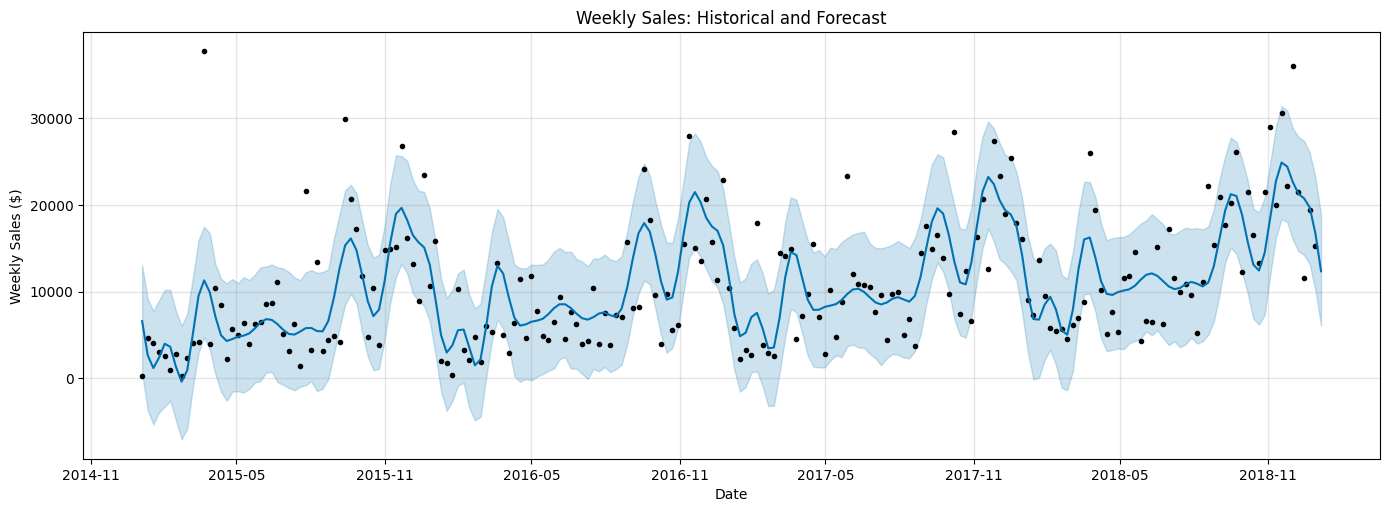

In [17]:
fig = model_final.plot(forecast_final, figsize=(14, 5))
plt.title('Weekly Sales: Historical and Forecast')
plt.xlabel('Date')
plt.ylabel('Weekly Sales ($)')
plt.show()

## Findings

Daily forecasting on this dataset proved unreliable due to high day-to-day volatility. Weekly aggregation reduced the noise and produced a usable forecast.

| Method | MAPE | MAE |
|---|---|---|
| Daily Prophet | ~250% | $1,531 |
| Weekly Prophet | ~11% | $1,623 |

**Forecast for week ending 2019-01-06:** ~$12,400 (80% interval: ~$6,000 to ~$19,000).

Notes:
- Validation tested on the last 7 days/1 week of 2018 with the rest used for training
- Wide intervals reflect genuine uncertainty in this dataset (std > mean at daily level)
- Improvements would need external regressors (marketing spend, promotions) or a longer time series